In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [11]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/mousebrain.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('Isocortex L6', 'Isocortex L5'),
 ('Isocortex L5', 'Isocortex L4'),
 ('Isocortex L4', 'Isocortex L2/3'),
 ('Isocortex L2/3', 'HIP & CTXpl L1')]

In [18]:
import os

In [13]:
data = 'mousebrain_revised'
basis = 'spatial'
metric_name = 'time_score_edge'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        # metric_file = f'../logs/{data}/{model}/metric_{basis}_redo.csv'
        metric_file = f'../logs/{model}/real/{data}/metric_{basis}_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'../logs/{model}/real/{data}/metric_{basis}.csv'
        metric = pd.read_csv(metric_file)
        metric.set_index('Unnamed: 0', inplace=True)
        idx_name = f'{metric_name}_pred_t_norm_{edge}'
        if idx_name in metric.index:
            t_score = metric.loc[metric.index == idx_name, '0'].values[0]
            t_score = float(t_score)
            result[model] = t_score
        if model == 'scvelo':
            scv_idx_name = f'{metric_name}_fit_t_norm_{edge}'
            if scv_idx_name in metric.index:
                t_score = metric.loc[metric.index == scv_idx_name, '0'].values[0]
                t_score = float(t_score)
                result['scvelo_avg'] = t_score
    results[edge] = result
results

{'Isocortex L6 -> Isocortex L5': {'scvelo': 0.08910710514696,
  'scvelo_avg': 0.12444566031215804,
  'velovi': 0.4759954116992071,
  'unitvelo': 0.5269226708134155,
  'velovae': 0.619184241249969,
  'deepvelo_cui': 0.3500667127416537,
  'topovelo': 0.6104359845648794},
 'Isocortex L5 -> Isocortex L4': {'scvelo': 0.9875702679617822,
  'scvelo_avg': 0.9886280118387859,
  'velovi': 0.4040929225512981,
  'unitvelo': 0.1975051149117057,
  'velovae': 0.5247705953019963,
  'deepvelo_cui': 0.6707387322964464,
  'topovelo': 0.49424448284766503},
 'Isocortex L4 -> Isocortex L2/3': {'scvelo': 0.20491693787341525,
  'scvelo_avg': 0.07519915480643125,
  'velovi': 0.41267547481420314,
  'unitvelo': 0.30503473065526787,
  'velovae': 0.7369901547116737,
  'deepvelo_cui': 0.29480983144702966,
  'topovelo': 0.8018409676009132},
 'Isocortex L2/3 -> HIP & CTXpl L1': {'scvelo': 0.010562098855290148,
  'scvelo_avg': 0.09404155362932574,
  'velovi': 0.1110840005293456,
  'unitvelo': 0.9423385495930656,
  've

In [19]:
data = 'mousebrain_revised'
basis = 'spatial'
metric_name = 'spatial_time_consist'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo']
result = {}
for model in models:
    metric_file = f'../logs/{model}/real/{data}/metric_{basis}_redo.csv'
    if not os.path.exists(metric_file):
        metric_file = f'../logs/{model}/real/{data}/metric_{basis}.csv'
    metric = pd.read_csv(metric_file)
    metric.set_index('Unnamed: 0', inplace=True)
    idx_name = f'{metric_name}_pred_t_norm'
    t_score = metric.loc[metric.index == idx_name, '0'].values[0]
    t_score = float(t_score)
    result[model] = t_score
    if model == 'scvelo':
        scv_idx_name = f'{metric_name}_fit_t_norm'
        t_score = metric.loc[metric.index == scv_idx_name, '0'].values[0]
        t_score = float(t_score)
        result['scvelo_avg'] = t_score
result


{'scvelo': 0.36875633929124724,
 'scvelo_avg': 0.6872544124718963,
 'velovi': 0.4986975034077962,
 'unitvelo': 0.8463643391927084,
 'velovae': 0.6918033666636407,
 'deepvelo_cui': 0.5968264897664388,
 'topovelo': 0.8565171243914175}

In [20]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo_avg": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt_vj": "#cd8c95"
}

In [21]:
import os
save_dir = f'../results/results_0128/{data}/metrics'
os.makedirs(save_dir, exist_ok=True)

/tmp/ipykernel_3146872/2430049246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='time_score', data=df, palette=model_colors)


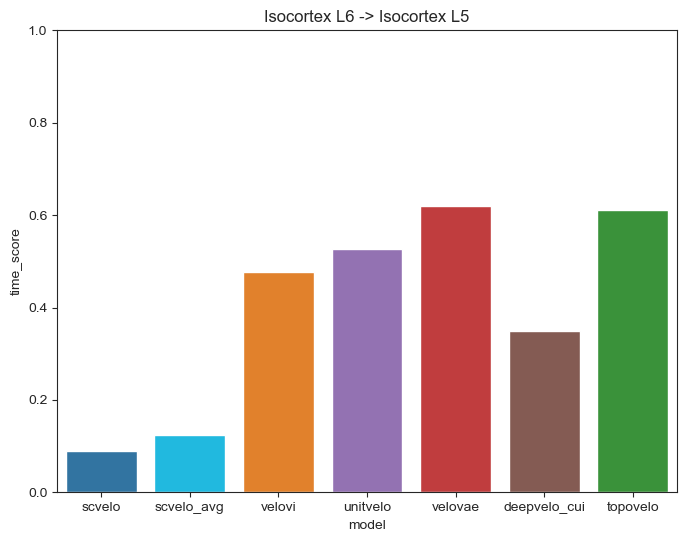

/tmp/ipykernel_3146872/2430049246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='time_score', data=df, palette=model_colors)


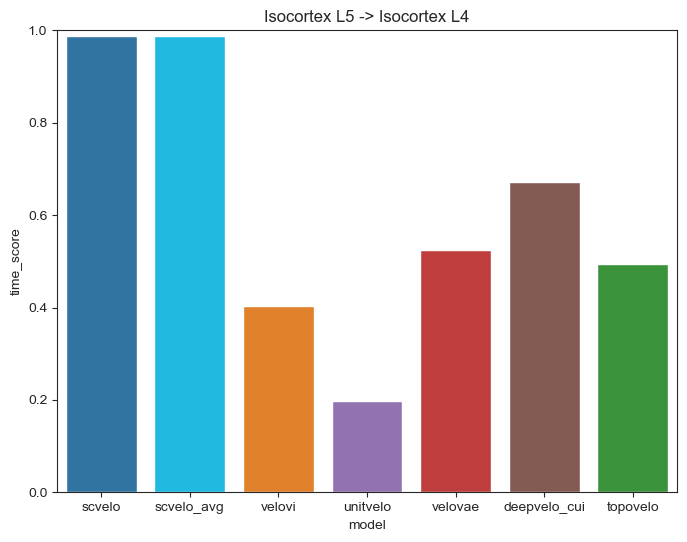

/tmp/ipykernel_3146872/2430049246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='time_score', data=df, palette=model_colors)


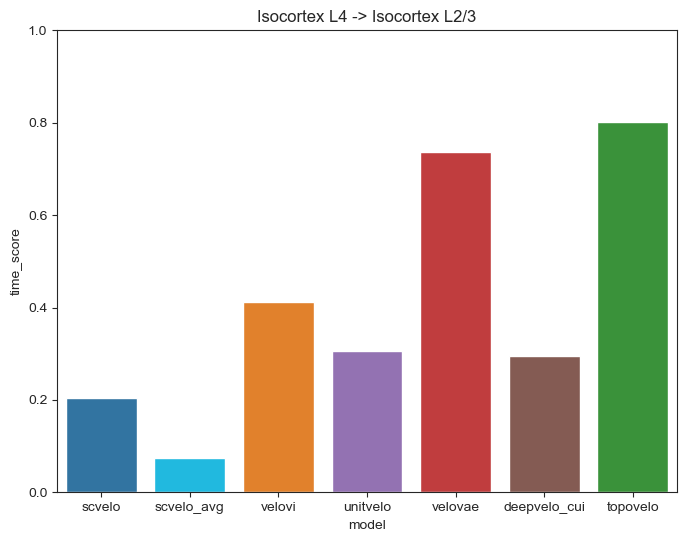

/tmp/ipykernel_3146872/2430049246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='time_score', data=df, palette=model_colors)


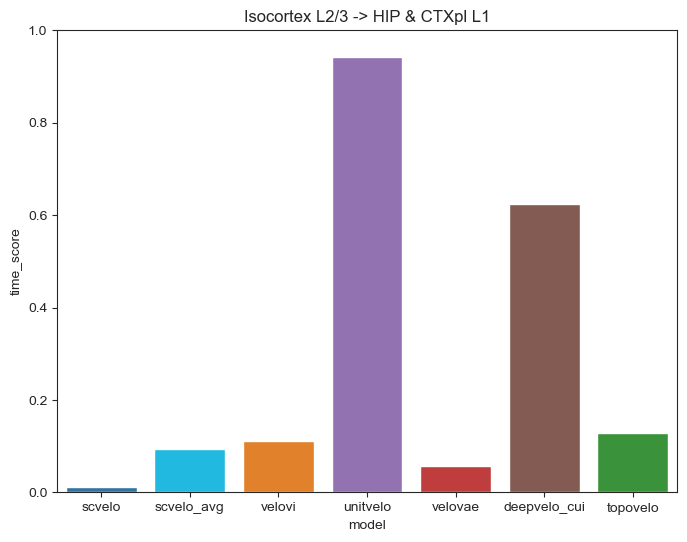

In [16]:
for key, value in results.items():
    df = pd.DataFrame(list(value.items()), columns=['model', metric_name])
    plt.figure(figsize=(8, 6))
    sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)
    plt.ylim(0, 1)
    plt.title(key)
    plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
    plt.show()

/tmp/ipykernel_3146872/394120003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)


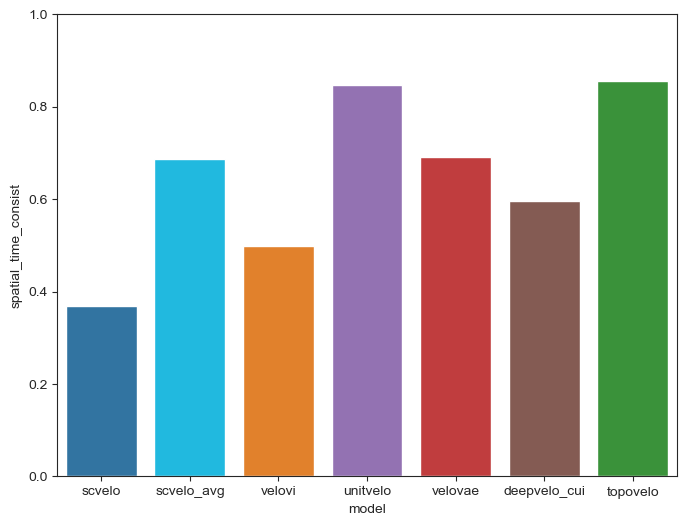

In [23]:
df = pd.DataFrame(list(result.items()), columns=['model', metric_name])
plt.figure(figsize=(8, 6))
sns.barplot(x='model', y=metric_name, data=df, palette=model_colors)
plt.ylim(0, 1)
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()